In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Literal

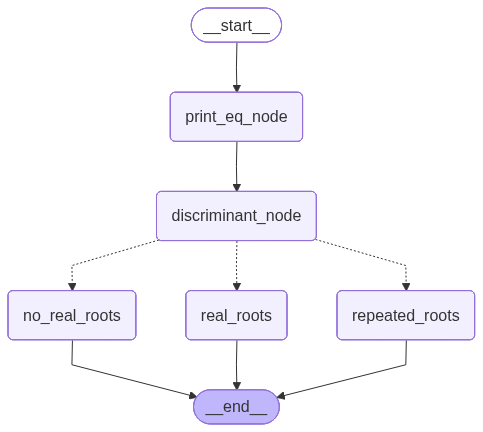

In [7]:
class QuadraticEQ(TypedDict):
    a : int
    b : int
    c : int

    equation : str
    discriminant: float

    result: str

graph = StateGraph(QuadraticEQ)

def print_eq(state: QuadraticEQ):
    equation = f'{state['a']}x2 + {state['b']}x + {state['c']}'

    return {'equation': equation}

def find_discriminant (state: QuadraticEQ):
    discriminant = state['b']**2 - (4* state['a'] * state['c'])

    return {'discriminant': discriminant}

def real_roots(state : QuadraticEQ):
    root1 = (-state['b'] + (state['discriminant']**0.5)/(2*state['a']))
    root2 = (-state['b'] - (state['discriminant']**0.5)/(2*state['a']))

    return {'result' : f'The roots are {root1} and {root2}'}

def repeated_roots(state : QuadraticEQ):
    root = (-state['b']/ (2*state['a']))

    return {'result' : f'The root is {root}'}

def no_real_roots(state : QuadraticEQ):

    return {'result' : f'No real roots'}

def check_condition(state:QuadraticEQ) -> Literal['real_roots', 'repeated_roots', 'no_real_roots']:
    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'repeated_roots'
    else: 
        return 'no_real_roots'

graph.add_node('print_eq_node', print_eq)
graph.add_node('discriminant_node', find_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'print_eq_node')
graph.add_edge('print_eq_node', 'discriminant_node')
graph.add_conditional_edges('discriminant_node' , check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)


workflow = graph.compile()
workflow

In [8]:
initial_state = {
    'a' : 4, 
    'b' : -5,
    'c' : -4
}

response = workflow.invoke(initial_state)

response

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x2 + -5x + -4',
 'discriminant': 89,
 'result': 'The roots are 6.179247641507075 and 3.820752358492925'}